In [ ]:
# In[1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# In[2]:

data = pd.read_csv("car_prices.csv", nrows = 10000)
data.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
# In[3]:

data.shape

(10000, 16)

In [ ]:
# In[4]:

data = data.drop(['vin', 'trim','saledate','state', 'mmr'], axis = 1)
data.shape

(10000, 11)

In [ ]:
# In[5]:

100*data.isnull().sum()/len(data)

year             0.00
make             0.25
model            0.26
body             2.44
transmission     7.81
condition       14.48
odometer         0.11
color            0.28
interior         0.28
seller           0.00
sellingprice     0.00
dtype: float64

In [ ]:
# In[6]:

data.describe()

,year,condition,odometer,sellingprice
count,10000.000000,8552.000000,9989.000000,10000.000000
mean,2009.675100,29.936038,68398.529282,14353.107100
std,4.143846,14.011239,54932.643853,11211.765516
min,1986.000000,1.000000,1.000000,1.000000
25%,2007.000000,23.000000,27949.000000,6600.000000
50%,2011.000000,34.000000,50395.000000,12400.000000
75%,2013.000000,41.000000,99334.000000,19500.000000
max,2015.000000,49.000000,999999.000000,154000.000000


In [ ]:
# In[7]:

data['condition'].fillna(data['condition'].mean(), inplace=True)
data['odometer'].fillna(data['odometer'].mean(), inplace=True)
data['sellingprice'].fillna(data['sellingprice'].mean(), inplace=True)
data['make'].fillna(data['make'].mode()[0], inplace=True)
data['model'].fillna(data['model'].mode()[0], inplace=True)
data['body'].fillna(data['body'].mode()[0], inplace=True)
data['transmission'].fillna(data['transmission'].mode()[0], inplace=True)
data['color'].fillna(data['color'].mode()[0], inplace=True)
data['interior'].fillna(data['interior'].mode()[0], inplace=True)
data['seller'].fillna(data['seller'].mode()[0], inplace = True)

In [ ]:
# In[8]:

100*data.isnull().sum()/len(data)

year            0.0
make            0.0
model           0.0
body            0.0
transmission    0.0
condition       0.0
odometer        0.0
color           0.0
interior        0.0
seller          0.0
sellingprice    0.0
dtype: float64

In [ ]:
# In[9]:

data['make'] = pd.factorize(data['make'])[0]
data['model'] = pd.factorize(data['model'])[0]
data['body'] = pd.factorize(data['body'])[0]
data['transmission'] = pd.factorize(data['transmission'])[0]
data['color'] = pd.factorize(data['color'])[0]
data['interior'] = pd.factorize(data['interior'])[0]
data['seller'] = pd.factorize(data['seller'])[0]

data.describe()

,year,make,model,body,transmission,condition,odometer,color,interior,seller,sellingprice
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2009.675100,14.120600,144.767900,3.07840,0.037500,29.936038,68398.529282,2.87970,1.797200,308.634400,14353.107100
std,4.143846,12.365838,124.065599,4.90378,0.189993,12.957067,54902.419563,3.08684,2.009248,374.135581,11211.765516
min,1986.000000,0.000000,0.000000,0.00000,0.000000,1.000000,1.000000,0.00000,0.000000,0.000000,1.000000
25%,2007.000000,4.000000,44.000000,1.00000,0.000000,25.000000,27956.000000,1.00000,0.000000,38.000000,6600.000000
50%,2011.000000,10.000000,127.500000,1.00000,0.000000,29.936038,50474.500000,2.00000,1.000000,132.000000,12400.000000
75%,2013.000000,23.000000,193.000000,3.00000,0.000000,39.000000,99168.000000,4.00000,4.000000,469.000000,19500.000000
max,2015.000000,71.000000,603.000000,32.00000,1.000000,49.000000,999999.000000,19.00000,15.000000,1502.000000,154000.000000


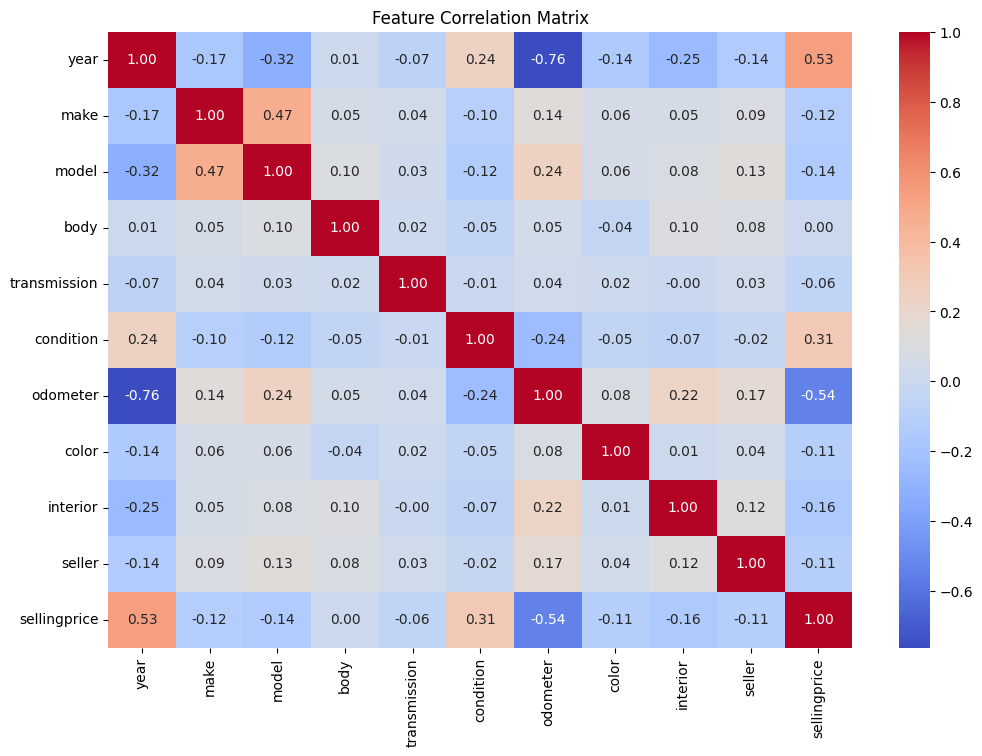

               year          make         model         body  transmission  \
count  10000.000000  10000.000000  10000.000000  10000.00000  10000.000000   
mean    2009.675100     14.120600    144.767900      3.07840      0.037500   
std        4.143846     12.365838    124.065599      4.90378      0.189993   
min     1986.000000      0.000000      0.000000      0.00000      0.000000   
25%     2007.000000      4.000000     44.000000      1.00000      0.000000   
50%     2011.000000     10.000000    127.500000      1.00000      0.000000   
75%     2013.000000     23.000000    193.000000      3.00000      0.000000   
max     2015.000000     71.000000    603.000000     32.00000      1.000000   

          condition       odometer        color      interior        seller  \
count  10000.000000   10000.000000  10000.00000  10000.000000  10000.000000   
mean      29.936038   68398.529282      2.87970      1.797200    308.634400   
std       12.957067   54902.419563      3.08684      2.00924

In [ ]:
# In[10]:

correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))  
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()
print(data.describe())

In [ ]:
# In[11]:

data = data[data['odometer'] < 500000]
data['odometer'] = np.log1p(data['odometer']) 
data['make'] = np.log1p(data['make']) 
data['model'] = np.log1p(data['model']) 
data['body'] = np.log1p(data['body']) 
data['seller']= np.log1p(data['seller'])

In [ ]:
# In[12]:

X = data.drop('sellingprice', axis = 1)
y = data['sellingprice']

In [ ]:
# In[13]:

norm = MinMaxScaler().fit(X)
X = norm.transform(X)

In [ ]:
# In[14]:

Linear_Regression = LinearRegression()
Linear_Regression.fit(X, y)
Linear_Regression.score(X, y)

0.35119044058687965

In [ ]:
# In[15]:

X2 = sm.add_constant(X)
est = sm.OLS(y, X2).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:           sellingprice   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     540.6
Date:                Wed, 11 Dec 2024   Prob (F-statistic):               0.00
Time:                        09:12:10   Log-Likelihood:            -1.0525e+05
No. Observations:                9998   AIC:                         2.105e+05
Df Residuals:                    9987   BIC:                         2.106e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6817.3542   1513.144      4.505      0.0

In [ ]:
# In[16]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [ ]:
# In[17]:

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# In[18]:

print('Train Accuracy = ', round((lr.score(X_train, y_train)), 4)*100,'%')
print('Test Accuracy = ', round((lr.score(X_test, y_test)), 4)*100,'%')

Train Accuracy =  35.08 %
Test Accuracy =  35.199999999999996 %


In [ ]:
# In[19]:

y_pred = lr.predict(X_test)
print(y_pred.round(2)[:5])
r2_score(y_test, y_pred)

[ 7636.32 25850.8  16800.8  18415.81 21457.54]


0.3520331268667144

In [ ]:
# In[20]:

pd.DataFrame({'Actual': y_test.round(2), 'Predicted': y_pred.round(2)})

,Actual,Predicted
4558,9800,7636.32
5362,21500,25850.80
962,30000,16800.80
1757,23000,18415.81
5857,18250,21457.54
...,...,...
162,6700,14580.39
4198,1650,7302.97
8047,15000,19348.46
8552,19000,17579.04


In [ ]:
# In[21]:

print("Mean Squared Error: ", mean_squared_error(y_test, y_pred).round(2))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred).round(2))  
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(y_test, y_pred)).round(2))

Mean Squared Error:  76850517.64
Mean Absolute Error:  5863.63
Root Mean Squared Error:  8766.44


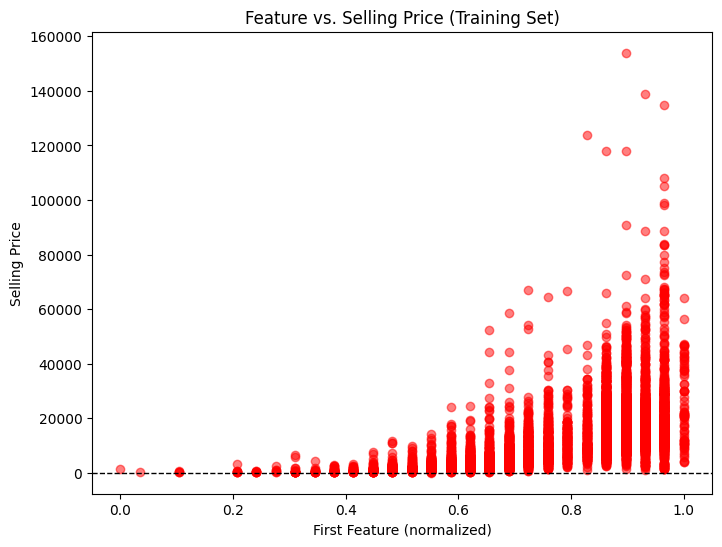

In [ ]:
# In[22]:

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], y_train, c='red', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature vs. Selling Price (Training Set)')
plt.xlabel('First Feature (normalized)')
plt.ylabel('Selling Price')
plt.show()

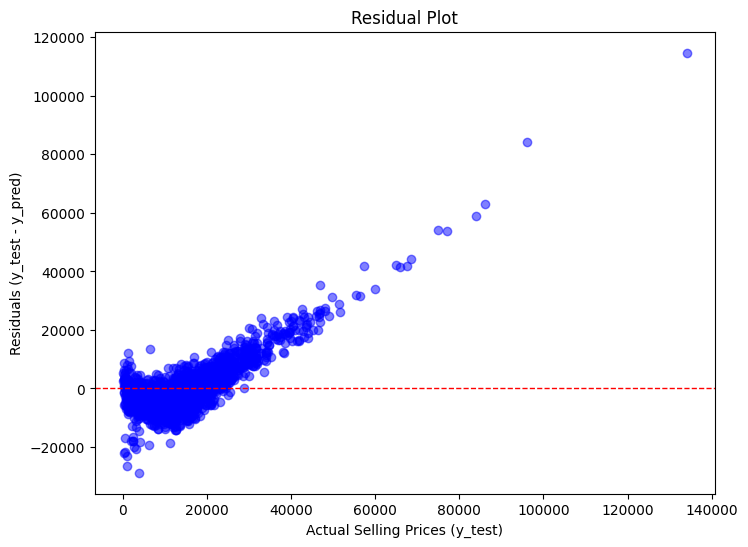

In [ ]:
# In[23]:

# Residual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test - y_pred, c='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot')
plt.xlabel('Actual Selling Prices (y_test)')
plt.ylabel('Residuals (y_test - y_pred)')
plt.show()

In [ ]:
# In[24]:

degree = 6
poly_reg = PolynomialFeatures(degree = degree)
X_poly = poly_reg.fit_transform(X)
pol_reg = LinearRegression()
pol_reg.fit(X_poly, y)

LinearRegression()

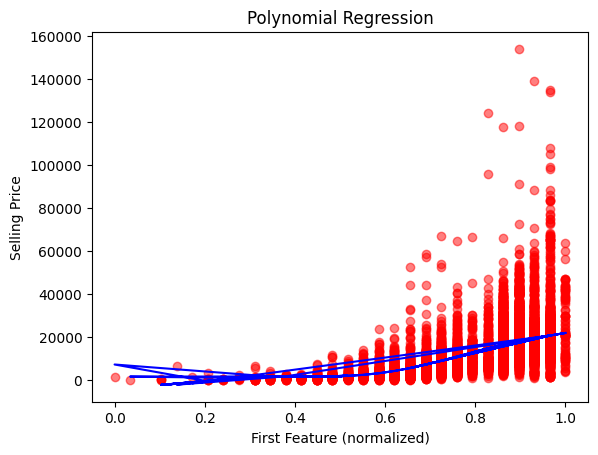

In [ ]:
# In[25]:

def viz_polymonial():
    X_feature = X[:, 0]
    X_feature = X_feature.reshape(-1, 1)

    poly_reg = PolynomialFeatures(degree=degree)
    X_poly = poly_reg.fit_transform(X_feature)
    pol_reg = LinearRegression()
    pol_reg.fit(X_poly, y)

    plt.scatter(X_feature, y, color='red', alpha=0.5)
    plt.plot(X_feature, pol_reg.predict(X_poly), color='blue')
    plt.title('Polynomial Regression')
    plt.xlabel('First Feature (normalized)')
    plt.ylabel('Selling Price')
    plt.show()

viz_polymonial()

In [ ]:
# In[26]:

print(Linear_Regression.predict(X).round())
print("R Square value:", r2_score(y, Linear_Regression.predict(X).round()))

[19546. 20520. 29202. ... 16403. 14115. 13932.]
R Square value: 0.35118999260554606


In [ ]:
# In[27]:

print(pol_reg.predict(poly_reg.fit_transform(X)).round())
print("R Square value:", r2_score(y, pol_reg.predict(poly_reg.fit_transform(X)).round()))

[22884. 22118. 29511. ... 20004.  8940.  9896.]
R Square value: 0.9019566619675953
